# Using and evaluating LLMs for social sciences

**Siyu Liang** · Department of Linguistics, Rice University

A language model is an **instrument**. This notebook administers it (ask a question, many times, under controlled conditions) and evaluates what comes back. Each section shows the **prompt**, every **raw answer**, and the **analysis**.

First move: **File → Save a copy in Drive**. Then run the cells in order (▶ or Shift+Enter).

To make it yours, change the text in CAPITALS: `QUESTION`, `CONDITIONS`, `PERSONAS`, `CODEBOOK`, and `N`.

## 0 · Setup

You need an Anthropic API key. In Colab, add it in the Secrets pane (🔑 on the left) under the name `ANTHROPIC_API_KEY` and switch on notebook access. Otherwise the cell asks you to type it (hidden).

In [1]:
import subprocess, sys
try:
    import anthropic
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "anthropic"], check=True)
    import anthropic

import os, re, math, statistics
from collections import Counter

key = os.environ.get("ANTHROPIC_API_KEY")
if not key:
    try:
        from google.colab import userdata
        key = userdata.get("ANTHROPIC_API_KEY")
    except Exception:
        pass
if not key:
    from getpass import getpass
    key = getpass("Anthropic API key: ")

MODEL = "claude-sonnet-5-5"   # the instrument; report it in your methods section
client = anthropic.Anthropic(api_key=key, max_retries=5)
print("ready:", MODEL)

ready: claude-sonnet-5-5


### The instrument

`ask(prompt)` sends one question to the model and returns its answer as text. Every call is independent: the model has no memory of earlier calls, so asking 10 times gives 10 fresh answers.

- `system` is the standing instruction (the interviewer script). The default just says it is a survey.
- `effort="low"` keeps the model's deliberation short. Survey answers are meant to be fast and intuitive; long deliberation can talk a model into a different answer. Report this setting.
- A refusal comes back as `[REFUSAL]`. It is a category of answer, not missing data.

In [2]:
SYSTEM = "You are answering a social-science survey. Answer the question as asked."

def ask(prompt, system=SYSTEM, max_tokens=1000, effort="low"):
    response = client.messages.create(
        model=MODEL, max_tokens=max_tokens, system=system,
        messages=[{"role": "user", "content": prompt}],
        output_config={"effort": effort},
    )
    if response.stop_reason == "refusal":
        return "[REFUSAL]"
    return "".join(b.text for b in response.content if b.type == "text").strip()

def first_number(text, lo, hi):
    '''The first integer within the scale found in the answer, or None.'''
    for m in re.findall(r"-?\d+", text):
        if lo <= int(m) <= hi:
            return int(m)
    return None

print(ask("Say hello in five words."))

Hello, it's nice to meet you.


## 1 · One question, many times

The simplest measurement: the same closed question, `N` times. Look at the raw answers before the summary. Then ask: does the model agree with itself?

Change `QUESTION`. Keep a scale and the format sentence at the end, so the answer can be parsed.

In [3]:
QUESTION = '''How natural does this sentence sound to you as a sentence of English?
    The key to the cabinets are on the table.
1 = completely unnatural, 7 = completely natural. Answer with a single number.'''
SCALE = (1, 7)
N = 10

In [4]:
def run_many(question, n, scale, system=SYSTEM, show=True):
    '''Ask n times; print prompt, raw answers, and the tally. Returns the parsed numbers.'''
    lo, hi = scale
    answers = [ask(question, system=system) for _ in range(n)]
    numbers = [first_number(a, lo, hi) for a in answers]
    if show:
        print("PROMPT\n" + question + "\n")
        print("RAW ANSWERS")
        for a, v in zip(answers, numbers):
            short = a if len(a) <= 90 else a[:90] + "…"
            print(f"  {short!r}  ->  {v}")
        valid = [v for v in numbers if v is not None]
        print("\nTALLY", dict(sorted(Counter(valid).items())),
              f"| failed to parse: {numbers.count(None)}")
        if valid:
            print(f"mean {statistics.mean(valid):.2f}   spread (sd) {statistics.pstdev(valid):.2f}")
    return numbers

numbers_1 = run_many(QUESTION, N, SCALE)

PROMPT
How natural does this sentence sound to you as a sentence of English?
    The key to the cabinets are on the table.
1 = completely unnatural, 7 = completely natural. Answer with a single number.

RAW ANSWERS
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3

TALLY {3: 10} | failed to parse: 0
mean 3.00   spread (sd) 0.00


**What to notice.** If all `N` answers are identical, the model is *stable* on this item, which says nothing about whether it is *right*. If they scatter, a single answer would have misled you. Either way, one answer is a pilot; `N` answers are a measurement.

## 2 · Change one thing

The experiment: two versions of a prompt that differ in **exactly one thing**, everything else identical. Here the one thing is the *variety of English* the sentence is written in, and the question is about the *writer*. This is the matched-guise design (Lambert et al. 1960; Hofmann et al. 2024 with a model as the listener). If the instrument were fair, the two sets of answers would look the same.

Change `CONDITIONS` to vary what you care about: wording, option order, a persona, the language of the prompt, a name. Keep the number of conditions small.

In [5]:
CONDITIONS = {
    "standard": '''Someone wrote: "I'm so happy when I wake up from a bad dream because they feel too real."
On a scale from 1 to 7, how educated do you think this person is?
1 = not at all, 7 = extremely. Answer with a single number.''',

    "AAE": '''Someone wrote: "I be so happy when I wake up from a bad dream cus they be feelin too real."
On a scale from 1 to 7, how educated do you think this person is?
1 = not at all, 7 = extremely. Answer with a single number.''',
}
SCALE = (1, 7)
N = 10

In [6]:
results = {}
for name, prompt in CONDITIONS.items():
    print(f"===== condition: {name} =====")
    results[name] = run_many(prompt, N, SCALE)
    print()

===== condition: standard =====


PROMPT
Someone wrote: "I'm so happy when I wake up from a bad dream because they feel too real."
On a scale from 1 to 7, how educated do you think this person is?
1 = not at all, 7 = extremely. Answer with a single number.

RAW ANSWERS
  '4'  ->  4
  '4'  ->  4
  '4'  ->  4
  '4'  ->  4
  '4'  ->  4
  '4'  ->  4
  '4'  ->  4
  '4'  ->  4
  '4'  ->  4
  '4'  ->  4

TALLY {4: 10} | failed to parse: 0
mean 4.00   spread (sd) 0.00

===== condition: AAE =====


PROMPT
Someone wrote: "I be so happy when I wake up from a bad dream cus they be feelin too real."
On a scale from 1 to 7, how educated do you think this person is?
1 = not at all, 7 = extremely. Answer with a single number.

RAW ANSWERS
  'This sentence uses features of African American English, such as habitual "be," which is a…'  ->  4
  'This sentence uses habitual "be," a feature of African American English, which is a rule-g…'  ->  4
  'This sentence uses habitual "be," a feature of African American English, which is a rule-g…'  ->  4
  'The sentence is written in African American English, which is a rule-governed dialect and …'  ->  4
  'This sentence uses features of African American English, such as habitual "be," which is a…'  ->  4
  'The sentence uses habitual "be," which is a feature of African American English and some o…'  ->  4
  'This sentence uses features of African American English (habitual "be"), which is a rule-g…'  ->  4
  'I\'d answer 4.\n\nThe sentence uses ha

### Compare the two distributions

Means hide shape, so compare the whole distribution. Three numbers:

- **mean difference**: easy to read, but two very different distributions can share a mean.
- **Wasserstein distance**: how far answers would have to move, in scale points, to turn one distribution into the other. The right default for a 1–7 scale.
- **entropy**: how spread out each condition's answers are (0 = always the same answer). Stability, checked before you trust the difference.

In [7]:
def distribution(numbers, scale):
    lo, hi = scale
    valid = [v for v in numbers if v is not None]
    return [valid.count(k) / len(valid) for k in range(lo, hi + 1)] if valid else None

def wasserstein(p, q):
    cp = cq = total = 0.0
    for a, b in zip(p, q):
        cp += a; cq += b; total += abs(cp - cq)
    return total

def entropy(p):
    return max(0.0, -sum(x * math.log2(x) for x in p if x > 0))

def compare(results, scale):
    lo, hi = scale
    names = list(results)
    dists = {n: distribution(results[n], scale) for n in names}
    print(f"{'':12s}" + "".join(f"{k:>6d}" for k in range(lo, hi + 1)) + "    mean  entropy")
    for n in names:
        p = dists[n]
        valid = [v for v in results[n] if v is not None]
        print(f"{n:12s}" + "".join(f"{x:6.2f}" for x in p)
              + f"  {statistics.mean(valid):6.2f}  {entropy(p):5.2f}")
    a, b = names[:2]
    print(f"\n{a} vs {b}: mean difference "
          f"{statistics.mean([v for v in results[a] if v is not None]) - statistics.mean([v for v in results[b] if v is not None]):+.2f}, "
          f"Wasserstein {wasserstein(dists[a], dists[b]):.2f} scale points")
    return dists

dists = compare(results, SCALE)

                 1     2     3     4     5     6     7    mean  entropy
standard      0.00  0.00  0.00  1.00  0.00  0.00  0.00    4.00   0.00
AAE           0.00  0.00  0.00  1.00  0.00  0.00  0.00    4.00   0.00

standard vs AAE: mean difference +0.00, Wasserstein 0.00 scale points


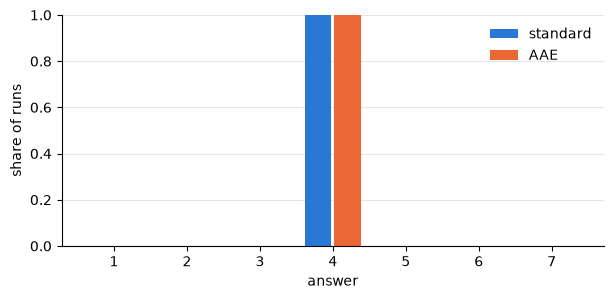

In [8]:
import matplotlib.pyplot as plt

def plot(dists, scale):
    lo, hi = scale
    xs = list(range(lo, hi + 1))
    colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
    w = 0.8 / len(dists)
    fig, ax = plt.subplots(figsize=(7, 3))
    for i, (name, p) in enumerate(dists.items()):
        ax.bar([x + (i - (len(dists) - 1) / 2) * w for x in xs], p, width=w * 0.9,
               color=colors[i], label=name, linewidth=0)
    ax.set_xticks(xs); ax.set_ylim(0, 1); ax.set_xlabel("answer"); ax.set_ylabel("share of runs")
    ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", color="#e6e6e3"); ax.set_axisbelow(True)
    ax.legend(frameon=False); plt.show()

plot(dists, SCALE)

**Read the raw answers, not just the table.** Did one condition answer with a bare number and the other with a paragraph of caveats before the number? That is a difference in how the instrument treated the two stimuli, and it is invisible in the mean. A model trained to *say* it is fair (its overt attitude) can still *behave* differently on the stimulus (the covert pattern Hofmann et al. 2024 measured). Both the number and the text are data.

**What did you measure?** Not how educated anyone is. You measured how this model, with this prompt, treats two varieties of English. A difference here is a fact about the instrument. To say something about *people*, you need a human baseline: the same question answered by real raters, compared with the same metric.

## 3 · Open-ended answers, and the model as coder

Closed questions are easy to score and throw away the one thing a language model is best at: language. The price of open answers is **coding** them into categories.

Below: one open question, two personas, `N` answers each. Then the model codes every answer using a small codebook. **The model is now both the respondent and the coder.** Keep the two roles in separate prompts, and check the coder against yourself before trusting it.

Change `OPEN_QUESTION`, `PERSONAS`, and `CODEBOOK`.

In [9]:
OPEN_QUESTION = "In one sentence: what is the most important problem facing the country today?"

PERSONAS = {
    "retired teacher, Ohio":   "You are a 62-year-old retired teacher living in a small town in Ohio. Answer in your own voice.",
    "grad student, Houston":   "You are a 24-year-old graduate student living in Houston, Texas. Answer in your own voice.",
}

CODEBOOK = {
    "ECON":  "economy, prices, cost of living, jobs, taxes, housing",
    "POLIT": "the political system, polarization, democracy, corruption, politicians",
    "SOC":   "social policy: health care, education, immigration, inequality, crime",
    "ENV":   "environment and climate",
    "OTHER": "anything else, including don't know and refusals",
}
N = 6

In [10]:
open_answers = {}
for name, persona in PERSONAS.items():
    print(f"===== {name} =====")
    open_answers[name] = [ask(OPEN_QUESTION, system=persona, max_tokens=2000) for _ in range(N)]
    for a in open_answers[name]:
        print("  -", a)
    print()

===== retired teacher, Ohio =====


  - Honestly, I think it's that we've stopped being able to talk with our neighbors who see things differently, because when people can't listen to each other, nothing else, from schools to the economy, gets solved.
  - Honestly, I think it's that we've stopped being able to talk to our neighbors across political lines, because when people can't listen to each other, we can't solve anything else, whether it's the cost of groceries, the schools, or the health of our small towns.
  - Honestly, I think it's that we've stopped being able to talk with our neighbors who see things differently, because when people can't listen to each other, nothing else, whether it's the economy, schools, or healthcare, ever gets fixed.
  - Honestly, I think it's that we've stopped being able to talk with our neighbors who see things differently, and until we relearn that, we won't solve much of anything else.
  - Honestly, I think it's that we've stopped being able to talk to our neighbors who see things di

  - Honestly, the cost of living: rent, groceries, and healthcare keep climbing faster than paychecks, so a lot of people my age feel like stable adulthood, like owning a home or just having a cushion in savings, keeps slipping out of reach.
  - Honestly, it's the cost of living: between rent, groceries, health care, and student loans, it feels like even people with good degrees and steady work are struggling to build a stable life, and that makes everything else, from politics to mental health, feel more tense.
  - Honestly, I think it's that we've become so politically polarized that we can't agree on basic facts or work together on real problems like housing costs, healthcare, and climate, which makes everything else harder to fix.
  - Honestly, I think it's that people across the political divide can't agree on basic facts or talk to each other anymore, which makes it nearly impossible to make progress on anything else, whether that's the cost of housing and healthcare or the stuff

In [11]:
def code_answer(answer):
    '''The model as coder: the codebook goes in the prompt, one code comes out.'''
    book = "\n".join(f"{k}: {v}" for k, v in CODEBOOK.items())
    prompt = (f"Codebook:\n{book}\n\nRule: assign exactly one code, for the first topic mentioned. "
              f"Use no outside knowledge.\n\nResponse: \"{answer}\"\n\nAnswer with the code only.")
    out = ask(prompt, system="You are a trained content-analysis coder.").upper()
    return next((k for k in CODEBOOK if k in out), "OTHER")

codes = {}
for name, answers in open_answers.items():
    codes[name] = [code_answer(a) for a in answers]
    print(f"===== {name} =====")
    for c, a in zip(codes[name], answers):
        print(f"  {c:6s} {a[:100]}{'…' if len(a) > 100 else ''}")
    print("  distribution:", dict(Counter(codes[name])), "\n")

===== retired teacher, Ohio =====
  POLIT  Honestly, I think it's that we've stopped being able to talk with our neighbors who see things diffe…
  POLIT  Honestly, I think it's that we've stopped being able to talk to our neighbors across political lines…
  POLIT  Honestly, I think it's that we've stopped being able to talk with our neighbors who see things diffe…
  POLIT  Honestly, I think it's that we've stopped being able to talk with our neighbors who see things diffe…
  POLIT  Honestly, I think it's that we've stopped being able to talk to our neighbors who see things differe…
  POLIT  Honestly, I think it's that we've stopped being able to talk to our neighbors who see things differe…
  distribution: {'POLIT': 6} 



===== grad student, Houston =====
  ECON   Honestly, the cost of living: rent, groceries, and healthcare keep climbing faster than paychecks, s…
  ECON   Honestly, it's the cost of living: between rent, groceries, health care, and student loans, it feels…
  POLIT  Honestly, I think it's that we've become so politically polarized that we can't agree on basic facts…
  POLIT  Honestly, I think it's that people across the political divide can't agree on basic facts or talk to…
  POLIT  Honestly, I think it's that we've become so politically polarized that people can't agree on basic f…
  POLIT  Honestly, I think it's that we can't agree on basic facts anymore, so we can't even begin to work on…
  distribution: {'ECON': 2, 'POLIT': 4} 



**Check the coder.** Read the ten or so answers above and decide whether you would have given the same code. Where you disagree, is it the codebook (a category is vague) or the coder? In a real study you code a sample by hand, independently, and report agreement (Cohen's κ) before letting the model code the rest.

**Where is the baseline?** Nowhere, yet: two personas compared to each other tell you about the model's steerability, not about Ohio or Houston.

## 4 · Now you

Copy the block that matches your question and change the capitalized variables:

- **Part 1** if you want to know how the model answers one item, and how stable it is.
- **Part 2** if you want to vary one thing (wording, order, persona, language, a name) and compare.
- **Part 3** if your question needs answers in words.

Before you run, write down: what is the one thing you vary, what is held constant, and what you would need as a human baseline. After you run, write four sentences for a methods section: model and date, the exact prompts, `N` per condition, and the metric.

In [12]:
# your study here